In [1]:
#Import packages and libraries
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles #import a dataset from sklearn

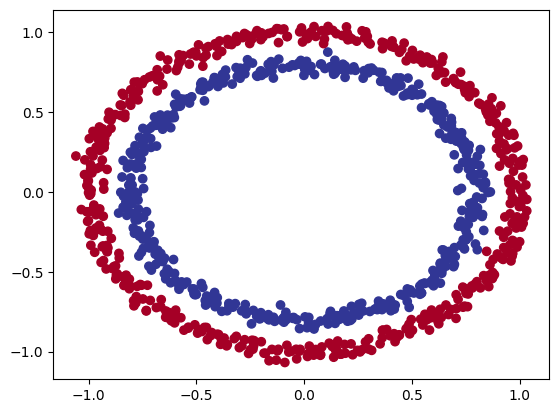

In [2]:

n_samples = 1000
X, y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [3]:
#Converting data to tensors -> to  train and test 
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [4]:
# build a non linear model  using the relu activation function

class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=10)
        self.layer2 = nn.Linear(in_features=10, out_features=10)
        self.layer3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() #relu is the non-linear activation function

    def forward(self, x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x))))) #applying the relu activation function at each layer
        

model_3 = CircleModelV2()
model_3

CircleModelV2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [5]:
model_3.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.6383,  0.0199],
                      [ 0.1528,  0.5710],
                      [-0.1459, -0.3098],
                      [-0.4998,  0.1374],
                      [-0.6784, -0.4101],
                      [-0.5480,  0.6035],
                      [-0.0932,  0.3948],
                      [-0.3973,  0.6717],
                      [ 0.6114, -0.5448],
                      [ 0.0788,  0.0573]])),
             ('layer1.bias',
              tensor([ 0.1056, -0.4857, -0.5968,  0.4487,  0.2599, -0.2882, -0.4345,  0.0564,
                       0.6373,  0.1534])),
             ('layer2.weight',
              tensor([[-0.2721,  0.0187,  0.1539,  0.0943,  0.2338, -0.1187, -0.1194, -0.0822,
                        0.0547,  0.2885],
                      [-0.0157,  0.0949,  0.2792,  0.2980, -0.1088,  0.1873, -0.0943,  0.1071,
                        0.2968,  0.0058],
                      [-0.1757, -0.0820, -0.2969,  0.1665,  0.0984,  0.1593

In [6]:
#creating the loss function
loss_fn = nn.BCEWithLogitsLoss()

#creating an optimizer
optimizer = torch.optim.SGD(params=model_3.parameters(),
                           lr=0.2)

In [7]:
#A funciton to calculate accuracy
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc

In [8]:
#training or testing

torch.manual_seed(42)

epochs = 1000

for  epoch in range(epochs):
    model_3.train()
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) #-> from logits data -> probabilities using sigmoid funciton -> predictions

    #calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    #optimizer zero grad
    optimizer.zero_grad() #Zeroing the gradient of the optimizer so it can start from scratch 

    #back propagation
    loss.backward()

    #optimizer step
    optimizer.step()

    #testing
    model_3.eval()
    with torch.inference_mode():
        #forward pass
        test_logits = model_3(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

    #calulate test_loss and accuracy
    test_loss = loss_fn(test_logits,
                       y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)


    #print the results
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Train_Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")
        

Epoch: 0 | Loss: 0.69469, Train_Acc: 50.00% | Test loss: 0.69468, Test Acc: 50.00%
Epoch: 10 | Loss: 0.69213, Train_Acc: 49.12% | Test loss: 0.69219, Test Acc: 49.50%
Epoch: 20 | Loss: 0.69106, Train_Acc: 50.88% | Test loss: 0.69109, Test Acc: 49.50%
Epoch: 30 | Loss: 0.69032, Train_Acc: 51.75% | Test loss: 0.69036, Test Acc: 53.00%
Epoch: 40 | Loss: 0.68970, Train_Acc: 51.50% | Test loss: 0.68974, Test Acc: 53.00%
Epoch: 50 | Loss: 0.68909, Train_Acc: 52.25% | Test loss: 0.68914, Test Acc: 53.50%
Epoch: 60 | Loss: 0.68850, Train_Acc: 53.00% | Test loss: 0.68854, Test Acc: 54.50%
Epoch: 70 | Loss: 0.68790, Train_Acc: 53.00% | Test loss: 0.68793, Test Acc: 54.00%
Epoch: 80 | Loss: 0.68732, Train_Acc: 53.75% | Test loss: 0.68732, Test Acc: 54.00%
Epoch: 90 | Loss: 0.68673, Train_Acc: 54.12% | Test loss: 0.68674, Test Acc: 54.00%
Epoch: 100 | Loss: 0.68614, Train_Acc: 54.62% | Test loss: 0.68612, Test Acc: 54.00%
Epoch: 110 | Loss: 0.68553, Train_Acc: 55.12% | Test loss: 0.68550, Test Acc

In [9]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py","wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

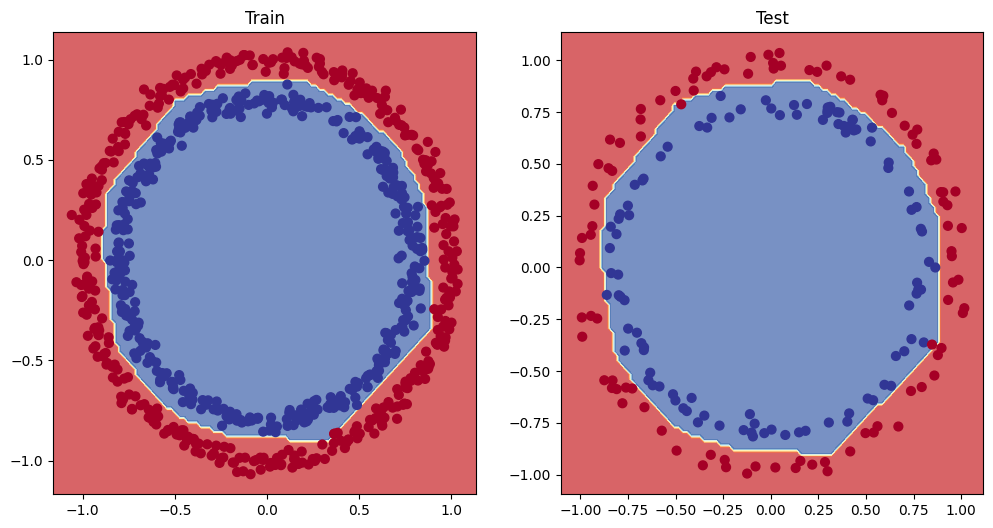

In [10]:
#plot decision boundary of the model

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3, X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, X_test,y_test)